# Capstone Black Box Project

## Function 7 - ML Tuning

optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1)

## Submission 10 of 13

In [1]:
# Cell 1 - Required imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern, WhiteKernel
import warnings
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import norm
from scipy.stats.qmc import LatinHypercube
from scipy.spatial.distance import cdist
import math

import sys
sys.path.append('./Utils')
from plot_progress import plot_progress
from plot_input_pairs import plot_nd_projection_matrix

## 1. Load Data

In [2]:
# Load the Input(X) and Output(y) data from the Black Box function's .npy files

function = "function_7"

def load_npy_files(function_name):
    inputs = np.load(f'./Data/{function_name}/merged_inputs.npy')
    outputs = np.load(f'./Data/{function_name}/merged_outputs.npy')
    return inputs, outputs

X, y = load_npy_files(function)

print(f"n = {len(y)}")
print(X[-2:])
print(y[-2:])

n = 39
[[0.141922 0.115034 0.20379  0.282529 0.341104 0.732189]
 [0.130864 0.149666 0.27462  0.29939  0.345033 0.643752]]
[2.69856289 2.90977509]


## 2. Describe and Review Data

In [3]:
# Review the inputs and outputs
dfX = pd.DataFrame(X)
print(dfX.describe())
dfy = pd.DataFrame(y)
print(dfy.describe())


               0          1          2          3          4          5
count  39.000000  39.000000  39.000000  39.000000  39.000000  39.000000
mean    0.413583   0.347404   0.368627   0.478370   0.445632   0.534565
std     0.321880   0.267319   0.295032   0.308784   0.278338   0.259508
min     0.014209   0.002763   0.003635   0.073659   0.014944   0.051100
25%     0.116729   0.115522   0.133695   0.205156   0.261781   0.354190
50%     0.319810   0.324495   0.274837   0.420385   0.387712   0.637476
75%     0.724450   0.524071   0.592354   0.781769   0.687320   0.729401
max     0.942451   0.924694   0.924571   0.977899   0.998655   0.951014
               0
count  39.000000
mean    0.527879
std     0.783450
min     0.002701
25%     0.019776
50%     0.100507
75%     0.607979
max     2.909775


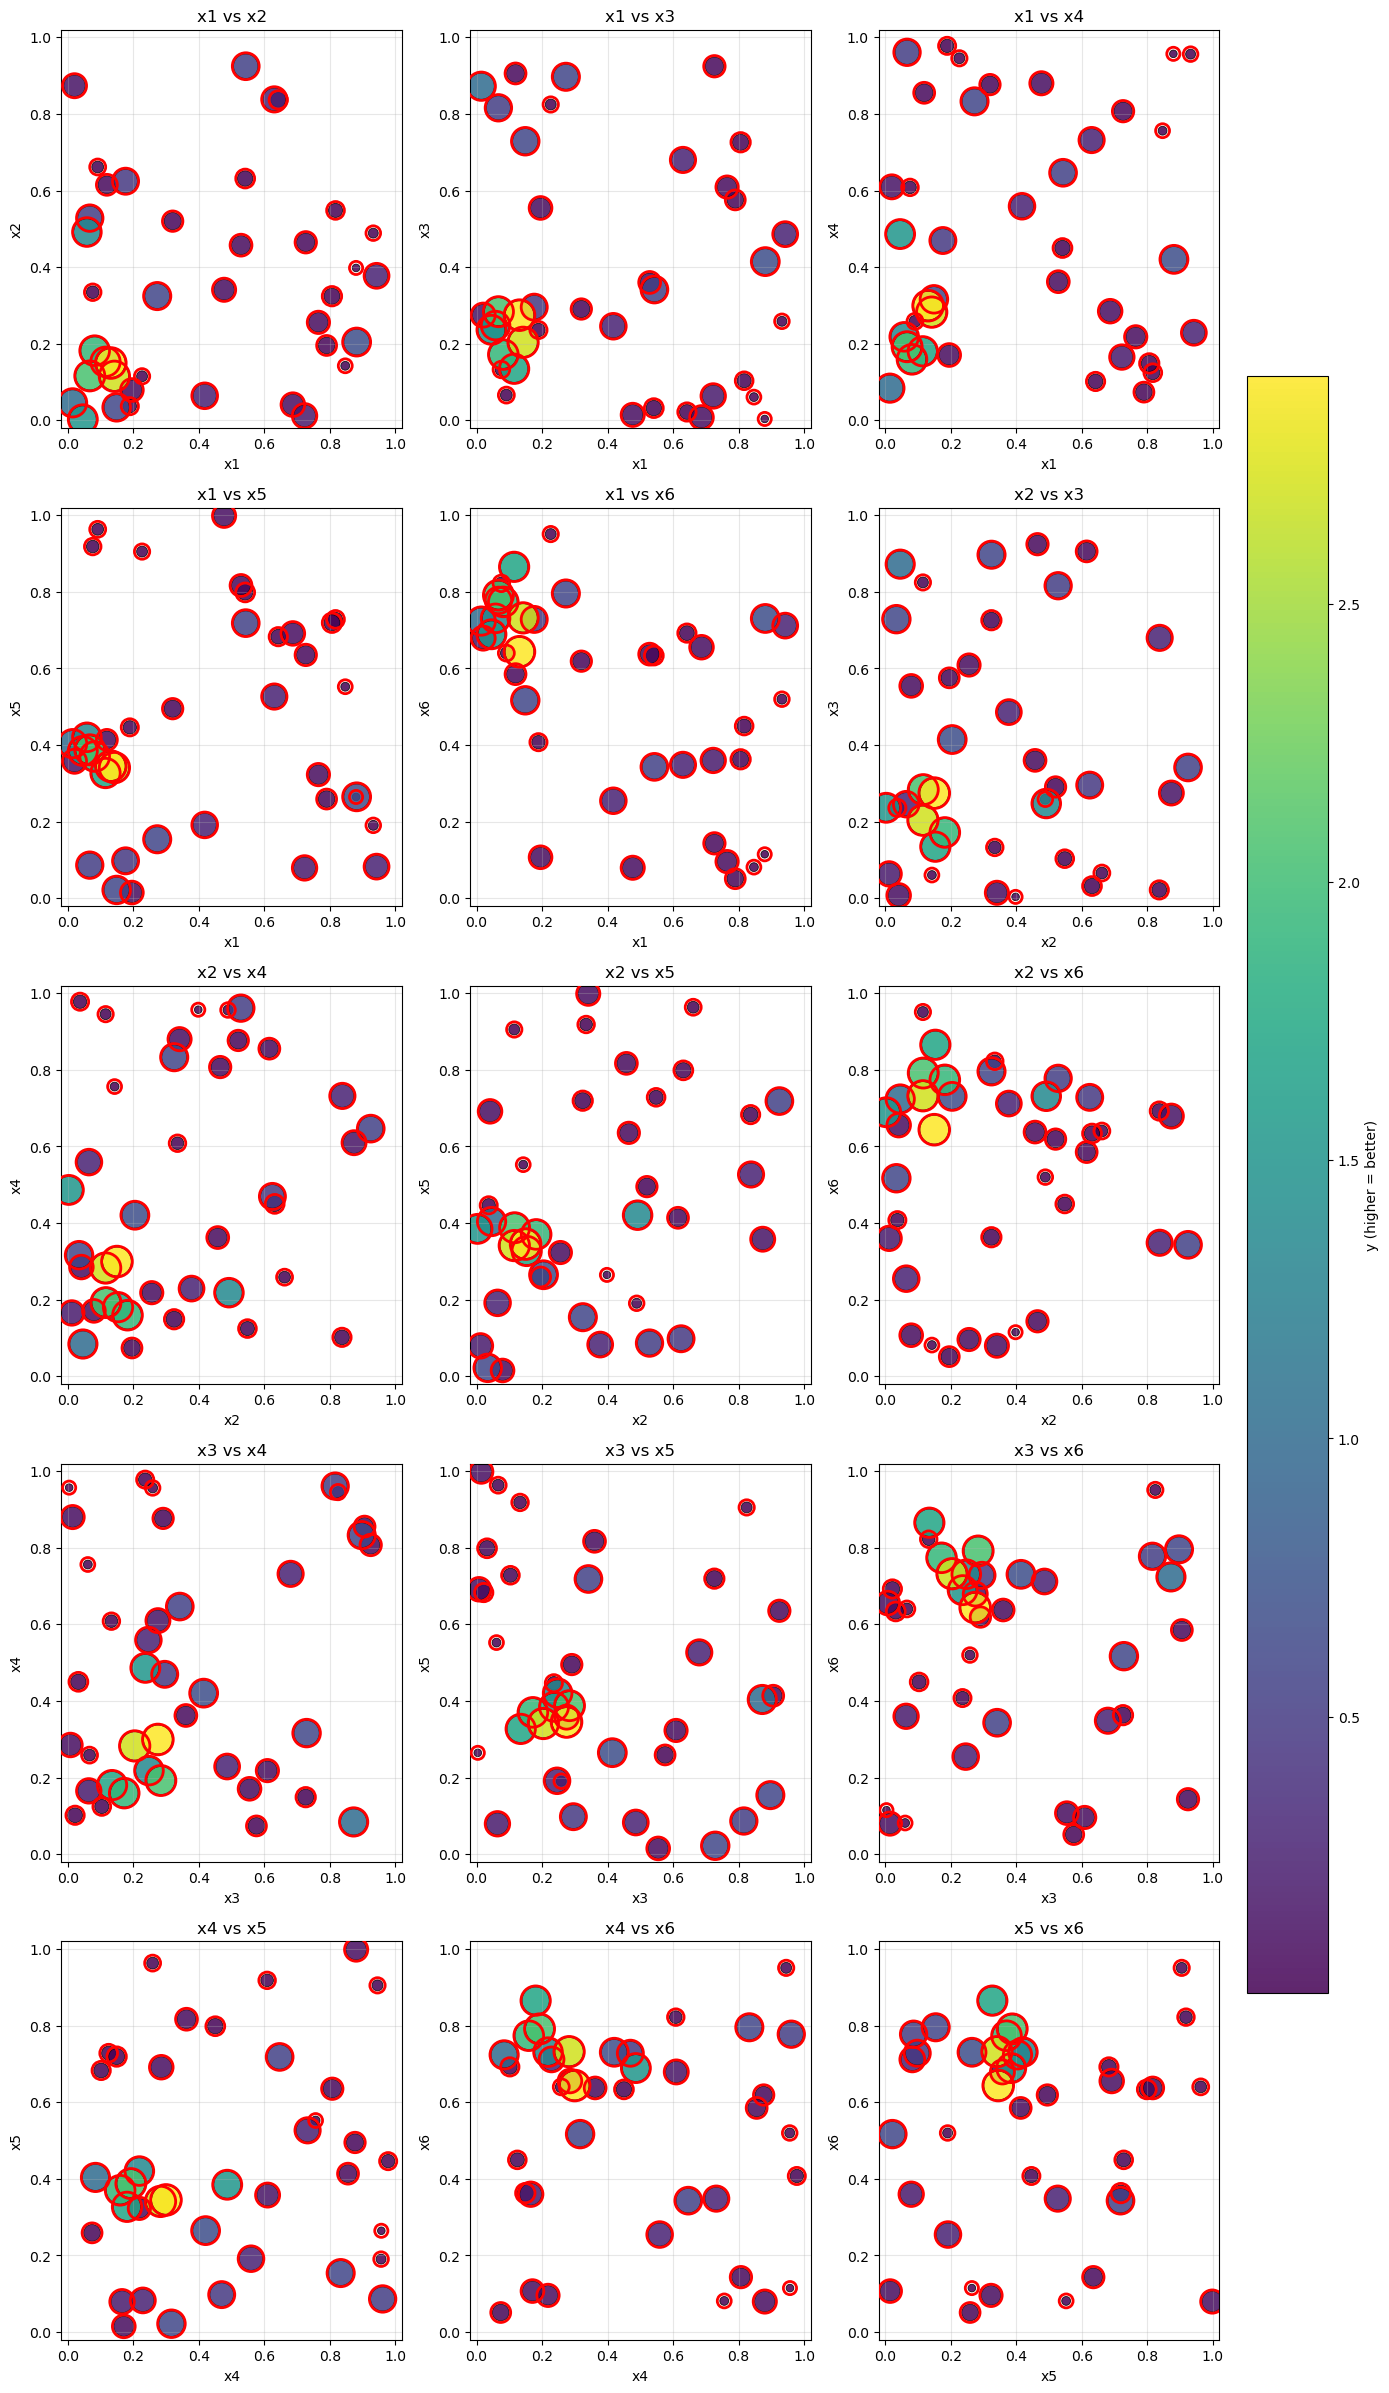

In [4]:
from scipy.stats import rankdata
from itertools import combinations

ridge_idx = np.where(y > 0)[0]   # or however you identify the ridge cluster
fig, axes = plot_nd_projection_matrix(X, y, highlight_idx=ridge_idx)
plt.savefig('./Figures/Function7_projection_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Transform Data

In [6]:
# No transforms applied

#y_fit = y
y_fit = np.log10(y) #wk 7 tranform

df_y = pd.DataFrame({
    "X1": X[:,0],
    "X2": X[:,1],
    "X3": X[:,2],
    "X4": X[:,3],
    "X5": X[:,4],
    "X6": X[:,5],
    "y": y,
    "y_fit": y_fit
})

output_file = f'./initial_data/{function}/y_transformations.csv'
df_y.to_csv(output_file, index=False)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'function_7 — y progression with running best'}, xlabel='Iteration (submission number)', ylabel='y'>)

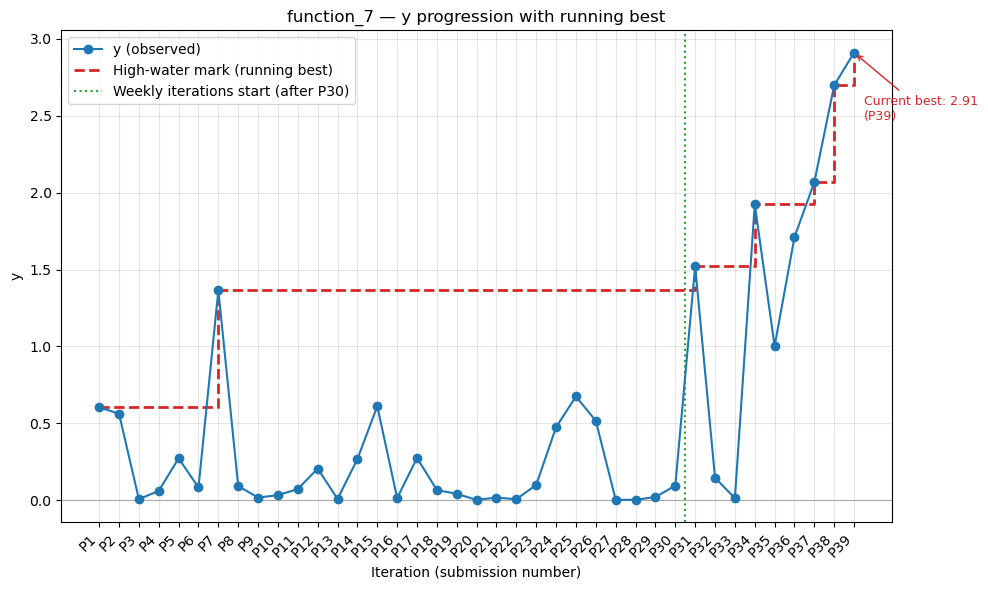

In [7]:
# Point labels and y values to monitor progress
# Plotting the untransformed values of y

plot_progress(y, labels=None, iteration_start=30, maximize=True,
                   objective_label="y", function_name=function,
                   save_path=None)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'function_7 — y_fit progression with running best'}, xlabel='Iteration (submission number)', ylabel='y_fit'>)

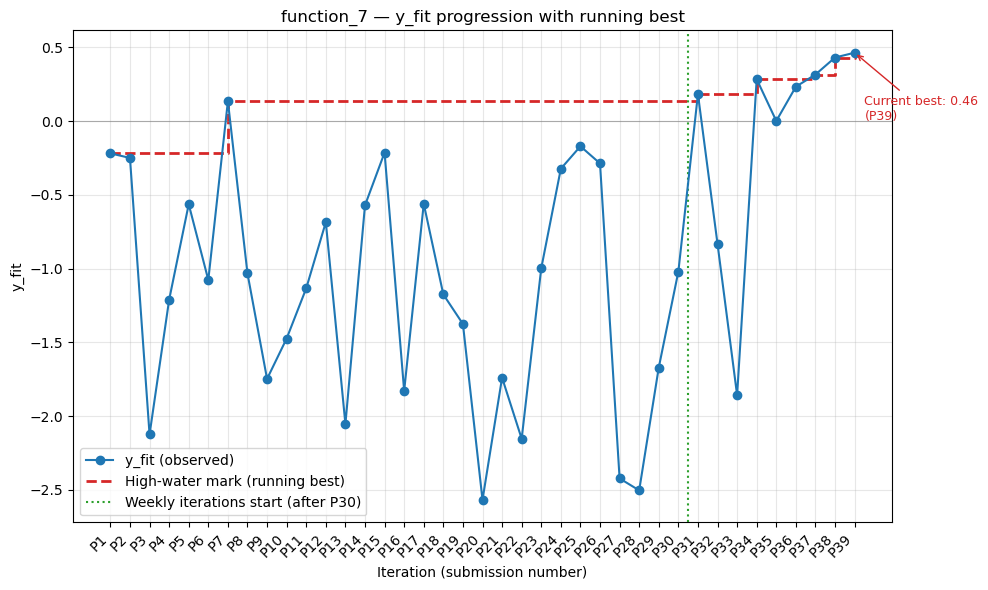

In [8]:
# Point labels and y values to monitor progress
# Plotting the transformed values of y_fit

plot_progress(y_fit, labels=None, iteration_start=30, maximize=True,
                   objective_label="y_fit", function_name=function,
                   save_path=None)

## 4. Fit Data to Kernal

In [9]:
# Compare alternative kernels

kernels = {
    'Matern_2.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=2.5),
    'Matern_1.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=1.5),
    'Matern_0.5': ConstantKernel(1.0, (0.01, 10)) * Matern(length_scale=0.3, length_scale_bounds=(0.05, 2.0), nu=0.5),
    # single scalar — isotropic
    'RBF1':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.3, length_scale_bounds=(0.05, 2.0)),
    'RBF2':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.25, 2.0)), 
    'RBF3':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.01, 10.0)), 
    'RBF4':        ConstantKernel(1.0, (0.01, 10)) * RBF(length_scale=0.25, length_scale_bounds=(0.01, 10.0))
                    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)),
    'RBF5':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=np.ones(X.shape[1]),length_scale_bounds=(0.05, 20.0)), #Wk6
    'RBF6':        ConstantKernel(1.0, constant_value_bounds=(0.01, 10)) * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(0.05, 2.0))
                    + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-5, 1.0)),
}

for name, k in kernels.items():
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always", category=ConvergenceWarning)
        gpr_test = GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=20, random_state=42)
        gpr_test.fit(X, y_fit)
    k_fitted = gpr_test.kernel_
    lml = gpr_test.log_marginal_likelihood_value_
    n_params = len(k_fitted.theta)
    aic = -2 * lml + 2 * n_params
    bic = -2 * lml + n_params * np.log(len(y))
    print(f"{name:12s}  LML={lml:.4f}  AIC={aic:.4f}  BIC={bic:.4f}  kernel={k_fitted}")

Matern_2.5    LML=-34.8761  AIC=73.7523  BIC=77.0794  kernel=1.08**2 * Matern(length_scale=0.687, nu=2.5)
Matern_1.5    LML=-36.0160  AIC=76.0319  BIC=79.3591  kernel=1.15**2 * Matern(length_scale=0.837, nu=1.5)
Matern_0.5    LML=-40.6408  AIC=85.2816  BIC=88.6087  kernel=1.18**2 * Matern(length_scale=1.54, nu=0.5)
RBF1          LML=-33.7483  AIC=71.4966  BIC=74.8237  kernel=0.968**2 * RBF(length_scale=0.501)
RBF2          LML=-33.7483  AIC=71.4966  BIC=74.8237  kernel=0.968**2 * RBF(length_scale=0.501)
RBF3          LML=-33.7483  AIC=71.4966  BIC=74.8237  kernel=0.968**2 * RBF(length_scale=0.501)
RBF4          LML=-33.7508  AIC=73.5016  BIC=78.4923  kernel=0.968**2 * RBF(length_scale=0.501) + WhiteKernel(noise_level=1e-05)
RBF5          LML=-29.1494  AIC=72.2989  BIC=83.9438  kernel=0.928**2 * RBF(length_scale=[0.8, 0.698, 0.652, 0.39, 0.36, 0.598])
RBF6          LML=-29.1528  AIC=74.3055  BIC=87.6140  kernel=0.928**2 * RBF(length_scale=[0.8, 0.698, 0.652, 0.39, 0.36, 0.598]) + WhiteK

In [10]:
# Fit Gaussian Process
# Select the best kernel for fitting
selected_kernel = 'RBF5'

kernel = kernels[selected_kernel]

gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)
gpr.fit(X, y_fit)
print(gpr.kernel_)

print(f"LML:       {gpr.log_marginal_likelihood_value_:.4f}")

0.928**2 * RBF(length_scale=[0.8, 0.698, 0.652, 0.39, 0.36, 0.598])
LML:       -29.1494


In [11]:
# Prediction Grid - Generate candidates and predict y

n_candidates = 10000
low = np.zeros(X.shape[1])
high = np.ones(X.shape[1])

rng = np.random.default_rng(42)
grid = rng.uniform(
low=low,
high=high,
size=(n_candidates, X.shape[1]))

print("Shape:", grid.shape)
print("Dimensions:", grid.ndim)
print("\nFirst 5 rows:")
print(grid[:5])
    
# GP predictions
mu, sigma = gpr.predict(grid, return_std=True)


Shape: (10000, 6)
Dimensions: 2

First 5 rows:
[[0.77395605 0.43887844 0.85859792 0.69736803 0.09417735 0.97562235]
 [0.7611397  0.78606431 0.12811363 0.45038594 0.37079802 0.92676499]
 [0.64386512 0.82276161 0.4434142  0.22723872 0.55458479 0.06381726]
 [0.82763117 0.6316644  0.75808774 0.35452597 0.97069802 0.89312112]
 [0.7783835  0.19463871 0.466721   0.04380377 0.15428949 0.68304895]]


## 5. Define Acquisition Function

In [12]:
 
xi_values = {
    "function_7": 0.05, #0.05 to 0.3 wk3
}

In [13]:
# Expected Improvement acquisition function
y_best = np.max(y_fit)


xi = xi_values.get(function, 0.1)

print(f"Using xi = {xi} for {function}")

improvement = mu - y_best - xi
Z = improvement / sigma

ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
ei[sigma == 0.0] = 0.0

# Pick next point
next_idx = np.argmax(ei)
print("Next Idx: ", next_idx)
next_x = grid[next_idx]

print("Current best y:", y_best)
print("Next point to evaluate:", next_x)
print("Formatted next point to evaluate:", "-".join(f"{x:.6f}" for x in next_x))
print("Expected improvement:", ei[next_idx])

print("Predicted mean:", mu[next_idx])
print("Predicted std:", sigma[next_idx])
print("Improvement:", mu[next_idx] - y_best - xi)

Using xi = 0.05 for function_7
Next Idx:  9967
Current best y: 0.4638594213472066
Next point to evaluate: [0.63472563 0.99460194 0.5874055  0.76774287 0.92451719 0.00333955]
Formatted next point to evaluate: 0.634726-0.994602-0.587405-0.767743-0.924517-0.003340
Expected improvement: 0.0476152069740617
Predicted mean: 0.017777348950698713
Predicted std: 0.521425835236505
Improvement: -0.49608207239650787


In [ ]:
# UCB acquisition function

# ---- ACQUISITION: GP-UCB (replaces EI) ----
kappa = 10
ucb = mu + kappa * sigma
 
next_idx = np.argmax(ucb)
 
print(f"\nUsing kappa = {kappa} for function_7")
print("Next Idx: ", next_idx)
print("Current best y:", y_best)
print("Next point to evaluate:", grid[next_idx])
print("UCB value:", ucb[next_idx])
print("Predicted mean:", mu[next_idx])
print("Predicted std:", sigma[next_idx])

In [14]:
#LHS for Function 7

x_best = X[np.argmax(y)]
print("x_best index:", np.argmax(y))

r = 0.10

bounds_low  = np.array([max(0.05, x_best[i] - r) for i in range(6)])
bounds_high = np.array([min(0.95, x_best[i] + r) for i in range(6)])

# Override x3 ceiling
bounds_high[2] = 0.30

sampler = LatinHypercube(d=6, seed=42)
lhs = sampler.random(n=50)
candidates = bounds_low + lhs * (bounds_high - bounds_low)

mu_c, _ = gpr.predict(candidates, return_std=True)

dmin = cdist(candidates, X).min(axis=1)
valid = dmin > 0.05

best_idx = np.argmax(mu_c[valid])
next_x = candidates[valid][best_idx]

print("Using Kernel: ", kernel)
print("Selected kernel: ", selected_kernel)
print(gpr.kernel_)
print("Next point:", next_x)
print("r radius:", r)
print("Formatted:", "-".join(f"{x:.6f}" for x in next_x))
print("mu:", mu_c[valid][best_idx])
print("mu (log10):", mu_c[valid][best_idx], "=> y ~", 10**mu_c[valid][best_idx])

x_best index: 38
Using Kernel:  1**2 * RBF(length_scale=[1, 1, 1, 1, 1, 1])
Selected kernel:  RBF5
0.928**2 * RBF(length_scale=[0.8, 0.698, 0.652, 0.39, 0.36, 0.598])
Next point: [0.05659512 0.11047239 0.28054474 0.33651215 0.32330463 0.70924276]
r radius: 0.1
Formatted: 0.056595-0.110472-0.280545-0.336512-0.323305-0.709243
mu: 0.4585776217100249
mu (log10): 0.4585776217100249 => y ~ 2.8746013269017867


In [16]:
# Fresh iso#1 candidate — same LHS trust region, scored under gpr_iso
x_best = X[np.argmax(y)]
r = 0.10

bounds_low  = np.array([max(0.05, x_best[i] - r) for i in range(6)])
bounds_high = np.array([min(0.95, x_best[i] + r) for i in range(6)])
bounds_high[2] = 0.30  # x3 ceiling

sampler = LatinHypercube(d=6, seed=42)
lhs = sampler.random(n=50)
candidates_iso = bounds_low + lhs * (bounds_high - bounds_low)

mu_iso_c, _ = gpr_iso.predict(candidates_iso, return_std=True)

dmin = cdist(candidates_iso, X).min(axis=1)
valid = dmin > 0.05

best_idx_iso = np.argmax(mu_iso_c[valid])
iso1_x = candidates_iso[valid][best_idx_iso]

print("Fresh iso#1 candidate:", iso1_x)
print("Formatted:", "-".join(f"{v:.6f}" for v in iso1_x))
print("mu (iso surface):", mu_iso_c[valid][best_idx_iso], "=> y ~", 10**mu_iso_c[valid][best_idx_iso])

Fresh iso#1 candidate: [0.16205352 0.08957361 0.25555941 0.34554249 0.24838791 0.70574782]
Formatted: 0.162054-0.089574-0.255559-0.345542-0.248388-0.705748
mu (iso surface): 0.5084449674532544 => y ~ 3.224370710452119


In [17]:
# wk9 maximin cross-rank — fit both surfaces explicitly (notebook uses one shared gpr)
from sklearn.gaussian_process import GaussianProcessRegressor

gpr_iso = GaussianProcessRegressor(kernel=kernels['RBF1'], normalize_y=True,
                                   n_restarts_optimizer=10, random_state=42).fit(X, y_fit)
gpr_ard = GaussianProcessRegressor(kernel=kernels['RBF5'], normalize_y=True,
                                   n_restarts_optimizer=10, random_state=42).fit(X, y_fit)

print("iso fitted:", gpr_iso.kernel_)
print("ard fitted:", gpr_ard.kernel_)
print()

cands = np.array([
    next_x,   # this week's fresh LHS pick
    iso1_x,   # this week's fresh iso/RBF1 LHS pick (from above)
])

mu_iso = gpr_iso.predict(cands)
mu_ard = gpr_ard.predict(cands)
for i, name in enumerate(['ARD#1', 'iso#1']):
    mm = min(mu_iso[i], mu_ard[i])
    print(f"{name}: iso={mu_iso[i]:.4f} (y~{10**mu_iso[i]:.3f})  "
          f"ard={mu_ard[i]:.4f} (y~{10**mu_ard[i]:.3f})  "
          f"maximin={mm:.4f} (y~{10**mm:.3f})")

winner = ['ARD#1', 'iso#1'][int(np.argmax([min(mu_iso[i], mu_ard[i]) for i in range(2)]))]
print(f"\nMaximin winner: {winner}")



iso fitted: 0.968**2 * RBF(length_scale=0.501)
ard fitted: 0.928**2 * RBF(length_scale=[0.8, 0.698, 0.652, 0.39, 0.36, 0.598])

ARD#1: iso=0.4596 (y~2.881)  ard=0.4586 (y~2.875)  maximin=0.4586 (y~2.875)
iso#1: iso=0.5084 (y~3.224)  ard=0.4371 (y~2.736)  maximin=0.4371 (y~2.736)

Maximin winner: ARD#1


In [20]:
#wk 10
candidate = np.array([0.130864, 0.149666, 0.274621, 0.299390, 0.345033, 0.580000])

mu_iso_c = gpr_iso.predict(candidate.reshape(1, -1))
mu_ard_c = gpr_ard.predict(candidate.reshape(1, -1))

print(f"iso: {mu_iso_c[0]:.4f}  (y~{10**mu_iso_c[0]:.3f})")
print(f"ard: {mu_ard_c[0]:.4f}  (y~{10**mu_ard_c[0]:.3f})")
print(f"maximin: {min(mu_iso_c[0], mu_ard_c[0]):.4f}  (y~{10**min(mu_iso_c[0], mu_ard_c[0]):.3f})")
print(f"Current best (P39): 0.4639  (y~2.910)")

iso: 0.4238  (y~2.653)
ard: 0.4421  (y~2.768)
maximin: 0.4238  (y~2.653)
Current best (P39): 0.4639  (y~2.910)


## 6. Plots for Uncertainty and Signal Strength 

In [ ]:
# --- Plot ---

